# Instacart — Análise do Comportamento de Compra e Recompra

Análise exploratória dos padrões de pedidos, recorrência de clientes e comportamento de recompra.

# Introdução

O Instacart é uma plataforma de entrega de supermercado onde os clientes podem fazer um pedido no supermercado e depois receber sua compra, semelhante ao funcionamento do Uber Eats e do iFood. O conjunto de dados que fornecemos foi modificado a partir do original. Reduzimos o tamanho dele para que seus cálculos sejam executados mais rapidamente e incluímos valores ausentes e duplicados. Também tivemos o cuidado de preservar as distribuições dos dados originais quando fizemos as alterações.

Você precisa completar três etapas. Para cada uma delas, escreva uma breve introdução descrevendo como você pretende concluir a etapa e justifique suas decisões em parágrafos explicativos a medida que você avança na solução. Escreva também uma conclusão para resumir suas conclusões e escolhas.



## Dicionário de dados

Há cinco tabelas no conjunto de dados, e você vai precisar usar todas elas para pré-processar seus dados e fazer AED. Abaixo está um dicionário que lista as colunas de cada tabela e descreve os dados contidos nelas.

- `instacart_orders.csv`: cada linha corresponde a um pedido no aplicativo da Instacart
    - `'order_id'`: é o número que identifica cada pedido de forma exclusiva
    - `'user_id'`: é o número de identificação exclusivo da conta de cada cliente
    - `'order_number'`: é o número de vezes que o cliente fez um pedido
    - `'order_dow'`: é o dia da semana em que o pedido foi feito (0 é domingo)
    - `'order_hour_of_day'`: é a hora do dia em que o pedido foi feito
    - `'days_since_prior_order'`: é o número de dias desde que o cliente fez seu pedido anterior




- `products.csv`: cada linha corresponde a um produto exclusivo que os clientes podem comprar
    - `'product_id'`: é o número de identificação unívoco de cada produto
    - `'product_name'`: é o nome do produto
    - `'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    - `'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado




-	`order_products.csv`: cada linha corresponde a um item incluído em um pedido
    -	`'order_id'`: é o número que identifica cada pedido de forma exclusiva
    -	`'product_id'`: é o número de identificação exclusivo de cada produto
    -	`'add_to_cart_order'`: é a ordem sequencial em que cada item foi colocado no carrinho
    -	`'reordered'`: 0 se o cliente nunca comprou o produto antes, 1 se já o comprou




-	`aisles.csv`
    -	`'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    -	`'aisle'`: é o nome do corredor



-	`departments.csv`
    -	`'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado
    -	`'department'`: é o nome do departamento


# Etapa 1. Visão geral dos dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
instacart_orders = pd.read_csv('/datasets/instacart_orders.csv')
products = pd.read_csv('/datasets/products.csv')
aisles = pd.read_csv('/datasets/aisles.csv')
departments = pd.read_csv('/datasets/departments.csv')
order_products = pd.read_csv('/datasets/order_products.csv')

In [3]:
instacart_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 1 columns):
 #   Column                                                                            Non-Null Count   Dtype 
---  ------                                                                            --------------   ----- 
 0   order_id;user_id;order_number;order_dow;order_hour_of_day;days_since_prior_order  478967 non-null  object
dtypes: object(1)
memory usage: 3.7+ MB


In [4]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 1 columns):
 #   Column                                          Non-Null Count  Dtype 
---  ------                                          --------------  ----- 
 0   product_id;product_name;aisle_id;department_id  49694 non-null  object
dtypes: object(1)
memory usage: 388.4+ KB


In [5]:
aisles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   aisle_id;aisle  134 non-null    object
dtypes: object(1)
memory usage: 1.2+ KB


In [6]:
departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 1 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   department_id;department  21 non-null     object
dtypes: object(1)
memory usage: 296.0+ bytes


In [7]:
order_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 1 columns):
 #   Column                                           Dtype 
---  ------                                           ----- 
 0   order_id;product_id;add_to_cart_order;reordered  object
dtypes: object(1)
memory usage: 34.7+ MB


### Conclusão

de inicio deu para perceber que existe apenas uma coluna em todos DF, isso faz com que as informações fiquem confusas para a interpretação do pandas.

os separadores estao errados.

todos os dados estao como STR.

# Etapa 2. Preparação dos dados

## Encontre e remova valores duplicados (e descreva por que você está fazendo suas escolhas)

### DataFrame `instacart_orders`

In [9]:
print(instacart_orders.duplicated().sum())

15


In [10]:

instacart_orders = pd.read_csv('/datasets/instacart_orders.csv', sep=';')
print(len(instacart_orders[(instacart_orders['order_hour_of_day'] == 2) & (instacart_orders['order_dow'] == 3)]))


121


In [11]:
instacart_orders = instacart_orders.drop_duplicates(subset=['order_id'])

In [12]:
print(instacart_orders.duplicated().sum())

0


In [13]:
print(instacart_orders['order_id'].duplicated().sum())

0


### Conclusão

fiz a escolha pensando no seguinte, 1 pedido, uma linha. o pedido deve ser unico.

### DataFrame `products`

In [15]:
products = pd.read_csv('/datasets/products.csv', sep=';')
print(products.duplicated().sum())

0


In [16]:
print(products['product_id'].duplicated().sum())

0


In [17]:
print(products['product_name'].str.lower().duplicated().sum())

1361


In [18]:
valid_names = products['product_name'].notna()
duplicates = products['product_name'].duplicated(keep=False)

duplicated_products = products[valid_names & duplicates]

print(duplicated_products)

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


### Conclusão

o 'Df' e a coluna 'product_id' não havia ids duplicados, isso indica que cada produto possui um identificador único.

porem com a analise mais profunda, existiam muitos nomes de produtos duplicados.

devido a isso, fiz uma conversao para minuscula e depois uma condição apenas para filtrar os nomes não nulos para garantir a eficacia da analise.

### DataFrame `departments`

In [20]:
departments = pd.read_csv('/datasets/departments.csv', sep=';')
print(departments.duplicated().sum())

0


In [21]:
print(departments['department_id'].duplicated().sum())

0


### Conclusão

O Df departments apresenta boa qualidade de dados, sem duplicações de registros ou da chave primária

### DataFrame `aisles`

In [23]:
aisles = pd.read_csv('/datasets/aisles.csv', sep=';')
print(aisles.duplicated().sum())

0


In [24]:
print(aisles['aisle_id'].duplicated().sum())

0


### Conclusão

O Df aisles apresenta boa qualidade de dados, sem duplicações de registros ou da chave primária

### DataFrame `order_products`

In [26]:
order_products = pd.read_csv('/datasets/order_products.csv', sep=';')
print(order_products.duplicated().sum())

0


In [27]:
order_products = pd.read_csv('/datasets/order_products.csv', sep=';')
print(order_products.duplicated().sum())
duplicated_order_product = order_products[['order_id', 'product_id']].duplicated().sum()
print("Combinações duplicadas de pedido + produto:", duplicated_order_product)

duplicated_cart_order = order_products[['order_id', 'add_to_cart_order']].duplicated().sum()
print("Posições duplicadas no carrinho:", duplicated_cart_order)

duplicated_positions = order_products[order_products[['order_id', 'add_to_cart_order']].duplicated(keep=False)]
same_position_diff_products = duplicated_positions.groupby(['order_id', 'add_to_cart_order'])['product_id'].nunique()
print("Pedidos com produtos diferentes na mesma posição:", (same_position_diff_products > 1).sum())

0
Combinações duplicadas de pedido + produto: 0
Posições duplicadas no carrinho: 766
Pedidos com produtos diferentes na mesma posição: 0


### Conclusão

O Df não apresenta duplicações completas nem inconsistências nas combinações de pedidos e produtos.

A presença de múltiplas ocorrências de 'order_id' e 'product_id' é esperada devido a relação dos dados.

Foram identificadas 766 duplicações na posição dos itens dentro do carrinho, porém sem conflitos de produtos.

## Encontre e remova valores ausentes


Ao processarmos valores duplicados, observamos que também temos valores ausentes que precisamos investigar nas seguintes colunas:

*	A coluna `'product_name'` da tabela products.
*	A coluna `'days_since_prior_order'` da tabela orders.
*	A coluna `'add_to_cart_order'` da tabela order_products.


### DataFrame `products`

In [29]:
print("=== Verificando valores ausentes na tabela products ===")
print()
print(products.isnull().sum())
print("\n=== Linhas com product_name ausente ===")
print()
print(products[products['product_name'].isnull()])

=== Verificando valores ausentes na tabela products ===

product_id          0
product_name     1258
aisle_id            0
department_id       0
dtype: int64

=== Linhas com product_name ausente ===

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]


In [30]:
produtos_sem_nome = products[products['product_name'].isnull()]
corredores_unicos = produtos_sem_nome['aisle_id'].unique()
print(f"Corredores únicos dos produtos sem nome: {corredores_unicos}")
print(f"Todos estão no corredor 100? {len(corredores_unicos) == 1 and corredores_unicos[0] == 100}")

Corredores únicos dos produtos sem nome: [100]
Todos estão no corredor 100? True


In [31]:
produtos_sem_nome = products[products['product_name'].isnull()]
departamentos_unicos = produtos_sem_nome['department_id'].unique()
print("Departamentos únicos dos produtos sem nome:", departamentos_unicos)

contagem_por_departamento = produtos_sem_nome['department_id'].value_counts()
print("Contagem por departamento:")
print(contagem_por_departamento)

todos_no_dept_21 = (produtos_sem_nome['department_id'] == 21).all()
print()
print("Todos os produtos sem nome estão no departamento 21?", todos_no_dept_21)

Departamentos únicos dos produtos sem nome: [21]
Contagem por departamento:
21    1258
Name: department_id, dtype: int64

Todos os produtos sem nome estão no departamento 21? True


In [32]:
# Use as tabelas department e aisle para verificar os dados do corredor com ID 100 e do departamento com ID 21.

corredor_100 = aisles[aisles['aisle_id'] == 100]
print("Informações do corredor ID 100:")
print(corredor_100)
print('------------')
departamento_21 = departments[departments['department_id'] == 21]
print("Informações do departamento ID 21:")
print(departamento_21)
print('------------')
produtos_corredor_100 = products[products['aisle_id'] == 100]
print(f"Total de produtos no corredor 100: {len(produtos_corredor_100)}")
print(f"Produtos com nome ausente: {produtos_corredor_100['product_name'].isnull().sum()}")
print(f"Produtos com nome válido: {produtos_corredor_100['product_name'].notna().sum()}")

Informações do corredor ID 100:
    aisle_id    aisle
99       100  missing
------------
Informações do departamento ID 21:
    department_id department
20             21    missing
------------
Total de produtos no corredor 100: 1258
Produtos com nome ausente: 1258
Produtos com nome válido: 0


In [33]:
# Preencha nomes de produtos ausentes com 'Unknown'

products['product_name'] = products['product_name'].fillna('Unknown')
print("Valores ausentes após preenchimento:")
print(products['product_name'].isnull().sum())
print()
print(f"Produtos com nome 'Unknown': {(products['product_name'] == 'Unknown').sum()}")

Valores ausentes após preenchimento:
0

Produtos com nome 'Unknown': 1258


### Conclusão

Os produtos com nomes ausentes estão concentrados exclusivamente no corredor 100 e no departamento 21

indicando que não se trata de dados faltantes aleatórios, mas sim de uma categoria específica de produtos sem identificação detalhada.

Isso sugere que esses itens podem representar produtos genéricos, sem categorizados ou dados incompletos do sistema.

### DataFrame `orders`

In [35]:
# Encontre os valores ausentes

print("=== Verificando valores ausentes na tabela instacart_orders ===")
print()
print(instacart_orders.isnull().sum())

print("\n=== Análise da coluna days_since_prior_order ===")
print(f"Valores ausentes: {instacart_orders['days_since_prior_order'].isnull().sum()}")
print(f"Total de registros: {len(instacart_orders)}")


=== Verificando valores ausentes na tabela instacart_orders ===

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64

=== Análise da coluna days_since_prior_order ===
Valores ausentes: 28817
Total de registros: 478952


In [36]:
# Há valores ausentes para os clientes que não estão fazendo o primeiro pedido?

valores_ausentes = (instacart_orders['order_number'] > 1) & (instacart_orders['days_since_prior_order'].isna())
print(f"Pedidos que não são o primeiro E têm days_since_prior_order ausente: {valores_ausentes.sum()}")

Pedidos que não são o primeiro E têm days_since_prior_order ausente: 0


### DataFrame `order_products`

In [37]:
# Encontre os valores ausentes

print(order_products.isnull().sum())

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64


In [38]:
# Quais são os valores mínimo e máximo dessa coluna?

print(order_products['add_to_cart_order'].min())
print(order_products['add_to_cart_order'].max())

1.0
64.0


In [39]:
# Salve todos os IDs dos pedidos com pelo menos um valor ausente em 'add_to_cart_order'

linhas_ausentes = order_products[order_products['add_to_cart_order'].isna()]
pedidos_ausentes = linhas_ausentes['order_id'].unique()
print(pedidos_ausentes)

[2449164 1968313 2926893 1717990 1959075  844733   61355  936852  264710
 1564093  129627  293169 2849370 1386261 3308010  903110 2136777 3347453
 1888628  165801 2094761 1038146 2997021  813364 2256933  171934 2409109
 1730767 1169835  733526  404157 3125735  747668 1800005 1961723  871281
  388234 1648217 1477139  102236 1021563 1832957 2721963  678116 1220886
 1673227 2999801 1633337 2470674 2625444 1677118 2479011 3383594 1183255
 1713430 2652650 1598369 1916118  854647 1302315  888470  180546 2621907
 1308785 2729254    9310 2170451 2979697 1625713 1529171]


In [45]:
pedidos_com_ausentes = order_products[order_products['order_id'].isin(pedidos_ausentes)]
contagem_por_pedido = pedidos_com_ausentes.groupby('order_id')['product_id'].count()
min_produtos = contagem_por_pedido.min()
print(f"Número mínimo de produtos em pedidos com valores ausentes: {min_produtos}")
print(f"Todos os pedidos têm mais de 64 produtos: {min_produtos > 64}")

Número mínimo de produtos em pedidos com valores ausentes: 65
Todos os pedidos têm mais de 64 produtos: True


In [46]:
# Substitua valores ausentes na coluna 'add_to_cart_order' por 999 e converta a coluna para o tipo integer

order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(999)
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].astype(int)

### Conclusão

O conjunto de dados apresenta boa qualidade geral, com estrutura consistente e integridade entre as tabelas.

Foram identificados alguns problemas, como duplicações em pedidos, inconsistências na padronização de nomes de produtos e valores ausentes em colunas específicas.

Esses problemas foram tratados com técnicas de limpeza de dados, incluindo remoção de duplicados, padronização textual e preenchimento de valores ausentes.

Destaca-se que os valores ausentes em 'product_name' não são aleatórios, estando concentrados em uma categoria específica, o que indica uma característica do sistema e não um erro.

Da mesma forma, os valores ausentes em 'days_since_prior_order' são consistentes com a lógica de negócio, ocorrendo apenas no primeiro pedido dos usuários.

Após o tratamento, os dados estão adequados para análises mais avançadas, como comportamento de compra, padrões de consumo e recomendações de produtos.

# Etapa 3. Análise de dados

## Análise temporal dos pedidos

### [A1] Verifique se os valores fazem sentido

In [57]:
print("Hora do dia - Min:", instacart_orders['order_hour_of_day'].min())
print("Hora do dia - Max:", instacart_orders['order_hour_of_day'].max()) 
print("Dia da semana - Min:", instacart_orders['order_dow'].min())
print("Dia da semana - Max:", instacart_orders['order_dow'].max())


Hora do dia - Min: 0
Hora do dia - Max: 23
Dia da semana - Min: 0
Dia da semana - Max: 6


In [58]:
print('== Quantidade de pedidos feitos das 0 as 23 hr  ==')
instacart_orders['order_hour_of_day'].value_counts().sort_index()



== Quantidade de pedidos feitos das 0 as 23 hr  ==


0      3180
1      1763
2       989
3       770
4       765
5      1371
6      4215
7     13043
8     25024
9     35896
10    40578
11    40032
12    38034
13    39007
14    39631
15    39789
16    38112
17    31930
18    25510
19    19547
20    14624
21    11019
22     8512
23     5611
Name: order_hour_of_day, dtype: int64

### [A2] Quantas pessoas fazem pedidos a cada hora do dia?

Text(0, 0.5, 'Quantidade de pedidos')

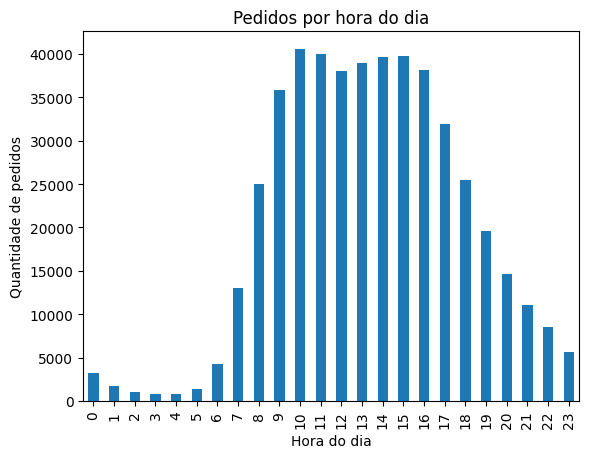

In [59]:
instacart_orders['order_hour_of_day'].value_counts().sort_index().plot(kind='bar')
plt.title('Pedidos por hora do dia')
plt.xlabel('Hora do dia')
plt.ylabel('Quantidade de pedidos')

### [A3] Em que dia da semana as pessoas compram produtos alimentícios?

Text(0, 0.5, 'Quantidade de pedidos')

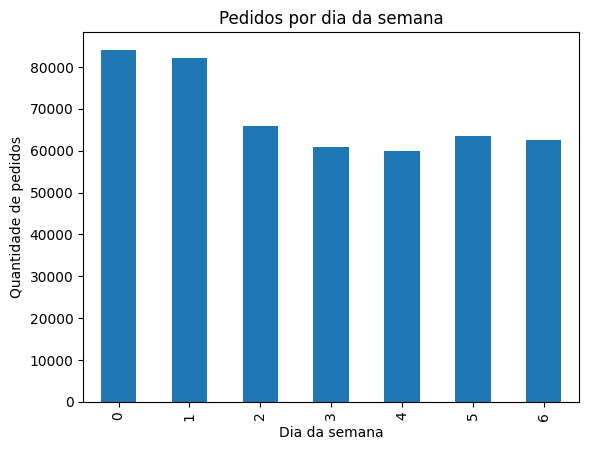

In [61]:
instacart_orders['order_dow'].value_counts().sort_index().plot(kind='bar')
plt.title('Pedidos por dia da semana')
plt.xlabel('Dia da semana')
plt.ylabel('Quantidade de pedidos')

### [A4] Quanto tempo as pessoas esperam até fazer outro pedido?

In [62]:
print("=== Estatísticas da coluna days_since_prior_order ===")
print(instacart_orders['days_since_prior_order'].describe())

=== Estatísticas da coluna days_since_prior_order ===
count    450135.000000
mean         11.101814
std           9.190004
min           0.000000
25%           4.000000
50%           7.000000
75%          15.000000
max          30.000000
Name: days_since_prior_order, dtype: float64


### Conclusão

A análise da variável 'days_since_prior_order' indica que os clientes realizam compras com frequência relativamente alta, com média de aproximadamente 11 dias entre pedidos.

A mediana de 7 dias sugere que a maior parte dos usuários possui um comportamento de compra semanal.

Observa-se também uma variação significativa nos intervalos, com valores que vão de compras no mesmo dia até intervalos de 30 dias, indicando diferentes perfis de consumo, desde clientes altamente frequentes até usuários com comportamento mais espaçado.

De forma geral, os dados revelam um padrão consistente de recompra, característico de produtos de consumo recorrente.

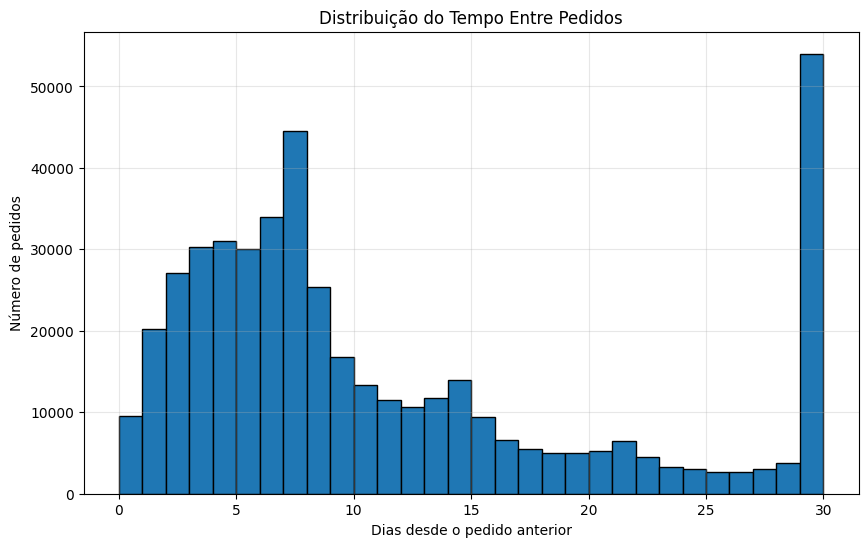

In [63]:
plt.figure(figsize=(10, 6))
instacart_orders['days_since_prior_order'].hist(bins=30, edgecolor='black')
plt.title('Distribuição do Tempo Entre Pedidos')
plt.xlabel('Dias desde o pedido anterior')
plt.ylabel('Número de pedidos')
plt.grid(True, alpha=0.3)
plt.show()

## Comportamento dos clientes e produtos

### [B1] Diferenças nas quartas e sábados em `'order_hour_of_day'`. Crie gráficos de barras para ambos os dias e descreva as diferenças.

In [84]:
quarta = instacart_orders[instacart_orders['order_dow'] == 3]

In [85]:
sabado = instacart_orders[instacart_orders['order_dow'] == 6]

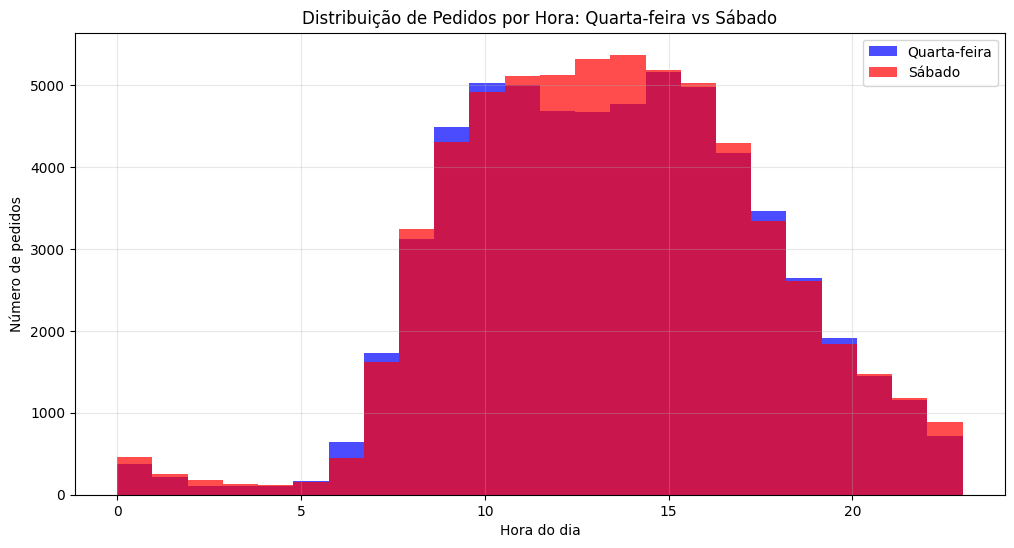

In [86]:
plt.figure(figsize=(12, 6))
plt.hist(quarta['order_hour_of_day'], bins=24, alpha=0.7, label='Quarta-feira', color='blue')
plt.hist(sabado['order_hour_of_day'], bins=24, alpha=0.7, label='Sábado', color='red')
plt.xlabel('Hora do dia')
plt.ylabel('Número de pedidos')
plt.title('Distribuição de Pedidos por Hora: Quarta-feira vs Sábado')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### [B2] Qual é a distribuição do número de pedidos por cliente?

In [67]:
pedidos_por_cliente = instacart_orders['user_id'].value_counts()
print("Primeiros 10 clientes e seus números de pedidos:")
print(pedidos_por_cliente.head(10))
print()
print("Estatísticas do número de pedidos por cliente:")
print(pedidos_por_cliente.describe())

Primeiros 10 clientes e seus números de pedidos:
149605    28
193164    26
78375     25
148162    24
66664     24
134511    24
54259     23
183981    23
106869    23
139660    23
Name: user_id, dtype: int64

Estatísticas do número de pedidos por cliente:
count    157437.000000
mean          3.042182
std           2.746842
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max          28.000000
Name: user_id, dtype: float64


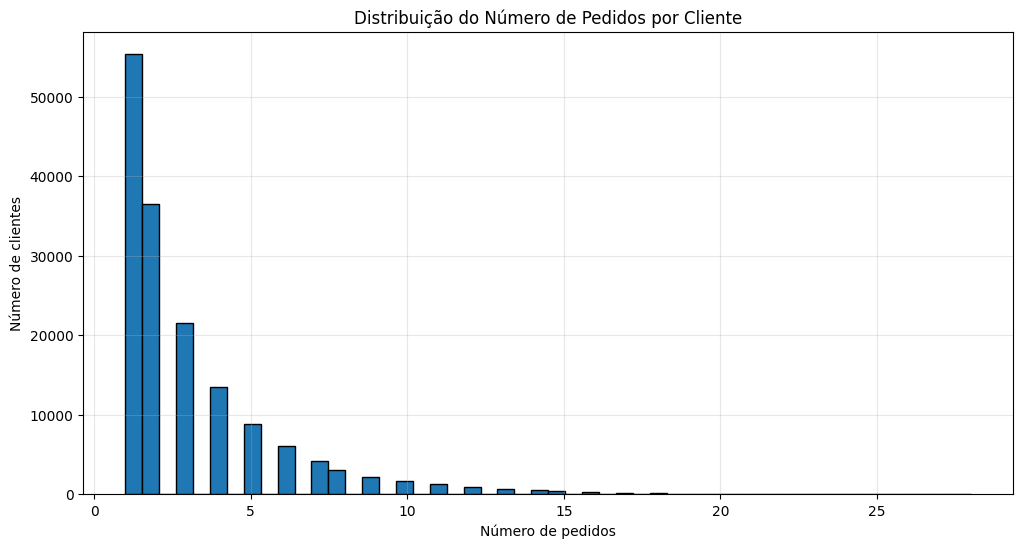

In [68]:
plt.figure(figsize=(12, 6))
pedidos_por_cliente.hist(bins=50, edgecolor='black')
plt.title('Distribuição do Número de Pedidos por Cliente')
plt.xlabel('Número de pedidos')
plt.ylabel('Número de clientes')
plt.grid(True, alpha=0.3)
plt.show()

### Conclusão

A análise do número de pedidos por cliente revela que a maioria dos usuários possui baixa recorrência, com mediana de 2 pedidos e média de aproximadamente 3 pedidos por cliente.

Observa-se, no entanto, a existência de um grupo reduzido de clientes altamente ativos, com até 28 pedidos, indicando diferentes perfis de comportamento.

A distribuição dos dados sugere um padrão típico de concentração, onde poucos clientes realizam grande parte das compras, enquanto a maioria apresenta baixa frequência de uso.

### [B3] Quais são os 20 produtos mais populares? Exiba os IDs e nomes.

In [73]:
produtos_populares = order_products['product_id'].value_counts()
print("Os 5 produtos mais populares (apenas IDs):")
print(produtos_populares.head())

Os 5 produtos mais populares (apenas IDs):
24852    66050
13176    53297
21137    37039
21903    33971
47209    29773
Name: product_id, dtype: int64


In [74]:
top_20_produtos = produtos_populares.head(20)
top_20_com_nomes = top_20_produtos.reset_index()
top_20_com_nomes.columns = ['product_id', 'frequencia']

In [75]:
resultado = top_20_com_nomes.merge(products, on='product_id')
print("Top 20 produtos mais populares:")
print(resultado[['product_id', 'product_name', 'frequencia']])

Top 20 produtos mais populares:
    product_id              product_name  frequencia
0        24852                    Banana       66050
1        13176    Bag of Organic Bananas       53297
2        21137      Organic Strawberries       37039
3        21903      Organic Baby Spinach       33971
4        47209      Organic Hass Avocado       29773
5        47766           Organic Avocado       24689
6        47626               Large Lemon       21495
7        16797              Strawberries       20018
8        26209                     Limes       19690
9        27845        Organic Whole Milk       19600
10       27966       Organic Raspberries       19197
11       22935      Organic Yellow Onion       15898
12       24964            Organic Garlic       15292
13       45007          Organic Zucchini       14584
14       39275       Organic Blueberries       13879
15       49683            Cucumber Kirby       13675
16       28204        Organic Fuji Apple       12544
17        5876

## Padrões de tamanho de pedido e recompra

### [C1] Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?

In [77]:
itens_por_pedido = order_products.groupby('order_id')['product_id'].count()
print(itens_por_pedido.describe())

count    450046.000000
mean         10.098983
std           7.540206
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
max         127.000000
Name: product_id, dtype: float64


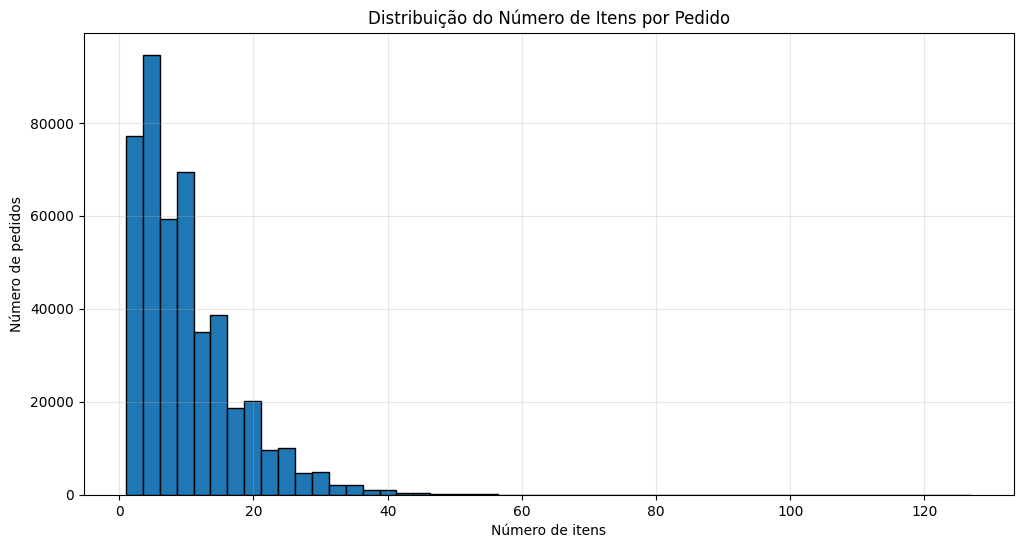

In [78]:
plt.figure(figsize=(12, 6))
itens_por_pedido.hist(bins=50, edgecolor='black')
plt.title('Distribuição do Número de Itens por Pedido')
plt.xlabel('Número de itens')
plt.ylabel('Número de pedidos')
plt.grid(True, alpha=0.3)
plt.show()

### Conclusão

A maioria dos pedidos contém entre 5 e 14 produtos, com uma média aproximada de 10 itens por pedido.

Observa-se uma alta variabilidade na quantidade de produtos, indicando a presença de pedidos significativamente maiores, com valores máximos chegando a 127 itens.

Isso sugere um comportamento heterogêneo dos usuários, variando entre compras pequenas e compras de grande volume.

### [C2] Quais são os 20 principais itens incluídos com mais frequência em pedidos repetidos? Exiba os IDs e nomes.

In [80]:
produtos_reordenados = order_products[order_products['reordered'] == 1]
print(f"Total de produtos reordenados: {len(produtos_reordenados)}")

Total de produtos reordenados: 2683838


In [81]:
contagem_reordenados = produtos_reordenados['product_id'].value_counts()
print("Top 5 produtos mais reordenados:")
print(contagem_reordenados.head())

Top 5 produtos mais reordenados:
24852    55763
13176    44450
21137    28639
21903    26233
47209    23629
Name: product_id, dtype: int64


In [82]:
top_20_reordenados = contagem_reordenados.head(20)
print(top_20_reordenados)

24852    55763
13176    44450
21137    28639
21903    26233
47209    23629
47766    18743
27845    16251
47626    15044
27966    14748
16797    13945
26209    13327
22935    11145
24964    10411
45007    10076
49683     9538
28204     8989
8277      8836
39275     8799
5876      8412
49235     8389
Name: product_id, dtype: int64


In [83]:
top_20_reordenados_df = top_20_reordenados.reset_index()
top_20_reordenados_df.columns = ['product_id', 'frequencia_reordenada']
resultado_reordenados = top_20_reordenados_df.merge(products, on='product_id')
print("Top 20 produtos mais reordenados:")
print(resultado_reordenados[['product_id', 'product_name', 'frequencia_reordenada']])

Top 20 produtos mais reordenados:
    product_id              product_name  frequencia_reordenada
0        24852                    Banana                  55763
1        13176    Bag of Organic Bananas                  44450
2        21137      Organic Strawberries                  28639
3        21903      Organic Baby Spinach                  26233
4        47209      Organic Hass Avocado                  23629
5        47766           Organic Avocado                  18743
6        27845        Organic Whole Milk                  16251
7        47626               Large Lemon                  15044
8        27966       Organic Raspberries                  14748
9        16797              Strawberries                  13945
10       26209                     Limes                  13327
11       22935      Organic Yellow Onion                  11145
12       24964            Organic Garlic                  10411
13       45007          Organic Zucchini                  10076
14    

### Conclusão

Os produtos mais reordenados são na maioria alimentos frescos, com destaque para frutas, vegetais e itens orgânicos.

A banana se destaca como o produto mais recorrente, indicando alta demanda e consumo frequente.

Observa-se que produtos perecíveis apresentam maior taxa de recompra, o que é consistente com seu ciclo de consumo mais curto.

Além disso, há uma forte presença de produtos orgânicos entre os mais reordenados, sugerindo uma preferência dos consumidores por esse tipo de item.

A distribuição das recompras é concentrada em poucos produtos, com uma queda significativa entre os mais populares e os demais.

# Conclusão geral do projeto:

### Conclusão

Nesse projeto eu analisei os dados de pedidos e produtos e percebi que, no geral, os dados estavam bem organizados, mas tinham alguns problemas como valores ausentes, duplicados e falta de padronização em nomes.

Durante a análise, consegui corrigir esses pontos e entender melhor o comportamento dos clientes. Foi possível ver que a maioria das pessoas faz poucos pedidos, mas existem alguns clientes que compram com muita frequência.

Também observei que os pedidos costumam ter em média cerca de 10 produtos e que muitos clientes compram novamente em um intervalo de aproximadamente uma semana.

Além disso, notei que produtos como frutas e itens orgânicos são os mais comprados novamente, mostrando um padrão de consumo frequente.

No final, os dados ficaram mais limpos e organizados, permitindo fazer análises e tirar conclusões sobre o comportamento dos usuários.